In [1]:
import pickle, sys, os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator

In [2]:
import NNMFit
from NNMFit.utilities.readout_graphs import HistogramGraph
from NNMFit.core.analysis_config import AnalysisConfig

In [3]:
sys.path.append("/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks")
from plot_utils import *

Lets add some systematics!!

In [4]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/inelasticity/plot_systematics"
os.system(f"mkdir -p {plotting_path}")

0

In [8]:
configs_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/configs/flavor_globalfit/"
config_hdl_systematics = AnalysisConfig.from_configs(
        main_config_file=f"{configs_dir}/main.cfg",
        analysis_config_file = f"{configs_dir}/analysis_configs/asimov/SAY/hese/hese_HESEBestfit_SPL.yaml",
        config_dir=configs_dir,
        override_dict=None,
        override_config_files=["override/systematics/NoSystematics_hese.cfg",
                               "override/datasets_hese/mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/bdt1_0.333333_bdt2_0.366667_length_10_combinedBaseline.cfg",
                               "override/binning/hese/10bdtprod_threshold_0.122.cfg"],
        override_components_files=["override/components/astro_SPL_3flavor.yaml",
                                   "override/muon/muontemplate_hese_11features_plus_rloglmilli_econf_evtgen_bdt1_0.333333_bdt2_0.366667.yaml"],
        override_parameters_files=None)
# build a histogram
hist_graph_hdl_systematics = HistogramGraph(config_hdl_systematics)
detector_configs = config_hdl_systematics.get_det_configs()

IC86_pass2_SnowStorm_FTP_HESE_Cascades


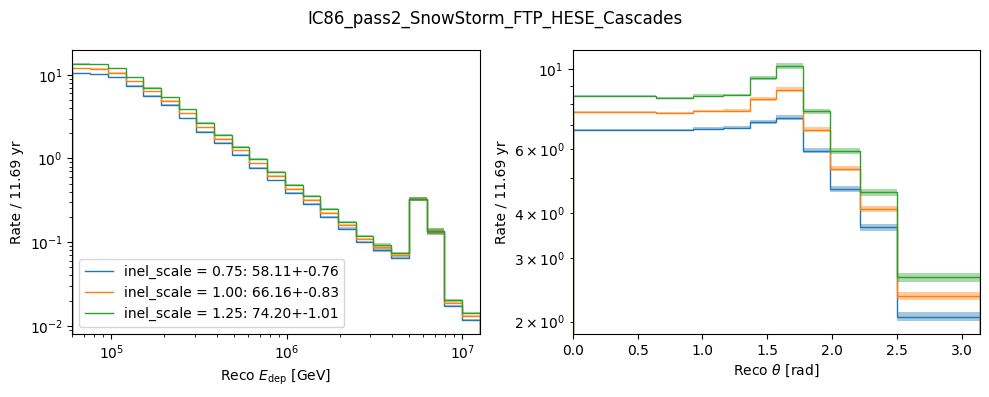

IC86_pass2_SnowStorm_FTP_HESE_Cascades


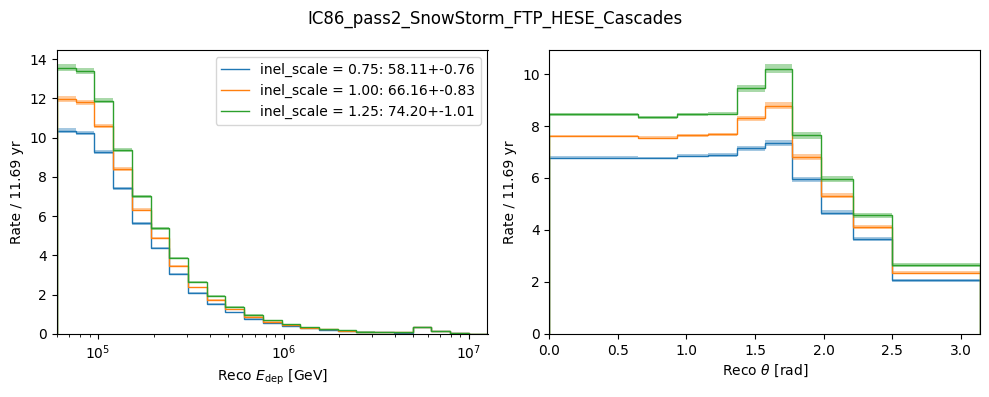

IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades


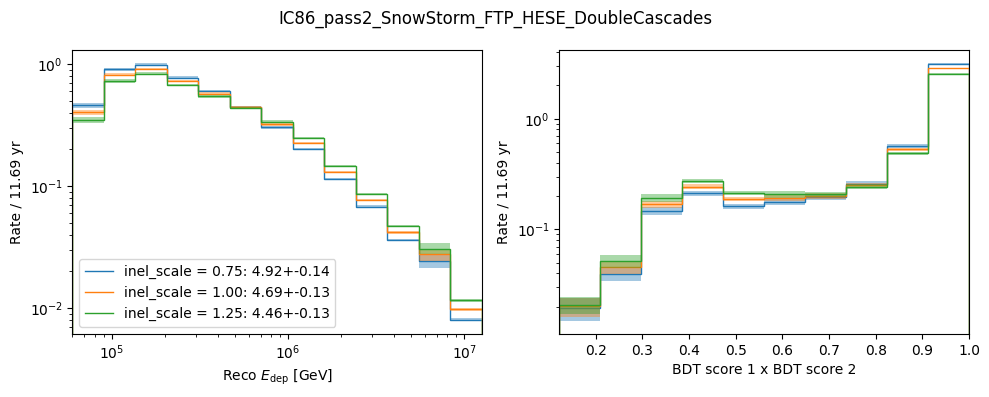

IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades


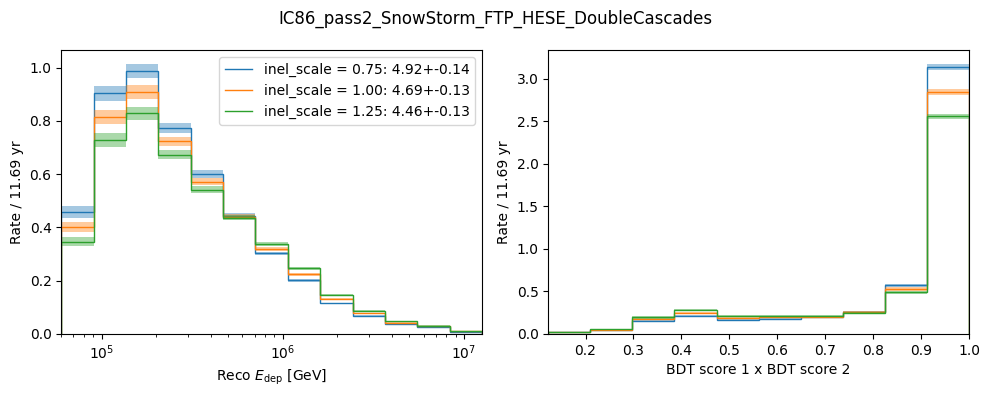

IC86_pass2_SnowStorm_FTP_HESE_Tracks


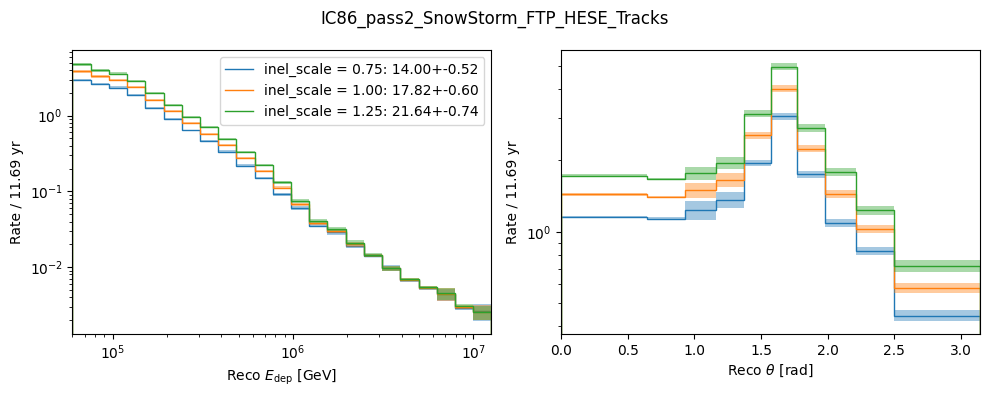

IC86_pass2_SnowStorm_FTP_HESE_Tracks


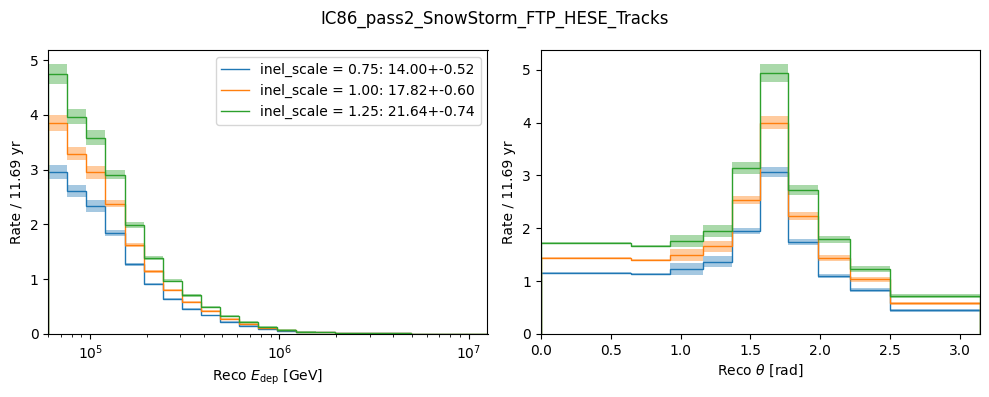

In [9]:
import numpy as np

# Parameter names
param_names = ["inel_scale"]

# Default values
default_values = [1.0]

# # Ranges for each parameter
# param_ranges = [
#     (0.5, 1.5),           # inel_scale
# ]

# half ranges
param_ranges = [
    (0.75, 1.25),           # inel_scale
]

n_points = 3  # how many points to sample in each range

for i, param in enumerate(param_names):
    # generate values in the range (linear spacing)
    values = np.linspace(param_ranges[i][0], param_ranges[i][1], n_points)

    # build input_variables dict for this parameter
    input_variables = {}
    for val in values:
        params = dict(zip(param_names, default_values))  # start from default
        params[param] = val                             # override current parameter
        input_variables[f"{param} = {val:.2f}"] = params

    # loop over detector configs and plot
    for det_config in detector_configs:
        for ylog in [True,False]:
            plot_histogram(
                hist_graph_hdl=hist_graph_hdl_systematics,
                det_config=det_config,
                input_variables=input_variables,
                ylog=ylog,
                savepath=f"{plotting_path}/{det_config}_{param}_ylog-{ylog}.png"
            )
